In [8]:
import langchain
langchain.__version__

'1.3.2'

In [1]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")




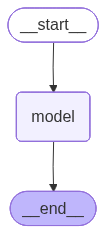

In [3]:
# Before tool calling. It behaves like simple gen ai application
from langchain.agents import create_agent

agent = create_agent(
    model = "gpt-5",
    tools = [],
    system_prompt = "You are a helpful assistant."
)
agent

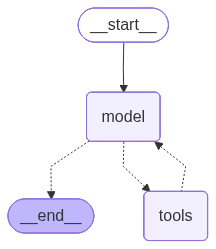

In [4]:
#With tool calling.
from langchain.agents import create_agent

def get_weather(location:str)->str:
    """Get the weather in a given location"""
    return f"The weather in {location} is sunny."

#tools = [get_weather]

agent = create_agent(
    model = "gpt-5",
    tools = [get_weather],
    system_prompt = "You are a helpful assistant."
)
agent

In [ ]:
#run the agent
#agent.run("What is the weather in Pune,India?")
agent.invoke({"messages":[{"role":"user", "content":"What is the weather in Pune,India?"}]})

{'messages': [HumanMessage(content='What is the weather in Pune,India?', additional_kwargs={}, response_metadata={}, id='1c3fcda6-2798-44c8-9cd2-579830994428'),
  AIMessage(content='', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 90, 'prompt_tokens': 144, 'total_tokens': 234, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 64, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-5-2025-08-07', 'system_fingerprint': None, 'id': 'chatcmpl-Dn5GyTRDJGKOpX5or9lQBmYcKQrp9', 'service_tier': 'default', 'finish_reason': 'tool_calls', 'logprobs': None}, id='lc_run--019e937a-0dbc-7dc0-9d9a-ffb922c09d6b-0', tool_calls=[{'name': 'get_weather', 'args': {'location': 'Pune, India'}, 'id': 'call_QIVvx9paRJAT0CLA0O9CUcPt', 'type': 'tool_call'}], invalid_tool_calls=[], usage_metadata={'input_tokens': 144, 'outp

In [7]:
response = agent.invoke({"messages":[{"role":"user", "content":"What is the weather in Pune,India?"}]})

response["messages"][-1].content

'The weather in Pune, India is sunny.'

In [9]:
## Model integration with Open AI, Google Gemini, GROQ
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")
os.environ["ANTHROPIC_API_KEY"] = os.getenv("ANTHROPIC_API_KEY")


In [14]:
from langchain.chat_models import init_chat_model

model = init_chat_model(
    model = "gpt-4.1"
)

model.invoke("Hello, How are you?")

AIMessage(content="Hello! I'm an AI, so I don't have feelings, but I'm here and ready to help you. How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 28, 'prompt_tokens': 13, 'total_tokens': 41, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_provider': 'openai', 'model_name': 'gpt-4.1-2025-04-14', 'system_fingerprint': 'fp_50f5de8b82', 'id': 'chatcmpl-Dn7FWdZGNfCKxF22oxIUxBjwppJbp', 'service_tier': 'default', 'finish_reason': 'stop', 'logprobs': None}, id='lc_run--019e93ee-0253-7e12-a8ca-92073baba2b4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 13, 'output_tokens': 28, 'total_tokens': 41, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})

In [2]:
#Google Gemini model integration
import os
from langchain.chat_models import init_chat_model
from litellm import google_genai

os.environ["GOOGLE_API_KEY"] = os.getenv("GOOGLE_API_KEY")

model = init_chat_model(
    "google_genai:gemini-2.5-flash-lite"
)

response = model.invoke("Do parrots talk?")

response.content


Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


'Yes, **parrots are famous for their ability to talk!**\n\nThis doesn\'t mean they *understand* language in the same way humans do, but they are incredibly skilled at mimicking sounds, including human speech. They can learn to say words, phrases, and even sing songs.\n\nHere\'s a breakdown of why and how they do it:\n\n*   **Vocalization:** Parrots have a syrinx, which is a vocal organ similar to our larynx, but it\'s located lower in their trachea. This allows them to produce a wide range of sounds.\n*   **Mimicry:** They are highly social creatures and often live in flocks. Mimicry is a way for them to communicate and bond with their flock members. When kept as pets, humans become their "flock."\n*   **Learning:** Parrots are intelligent and have a strong capacity for learning. They can associate sounds with specific contexts or rewards (like attention or treats).\n*   **Individual Differences:** Not all parrots are equally adept at talking. Some species are known for their exception

In [5]:
# GROQ model integration
import os
from dotenv import load_dotenv
load_dotenv()
os.environ["GROQ_API_KEY"] = os.getenv("GROQ_API_KEY")

from langchain.chat_models import init_chat_model

model = init_chat_model(
    model = "groq:qwen/qwen3-32b",
    api_key = os.getenv("GROQ_API_KEY")
)

response = model.invoke("Why do parrots talk?")

response.content




'<think>\nOkay, so I need to figure out why parrots talk. Let me start by recalling what I know about parrots. They\'re known for mimicking sounds, especially human speech. I remember that some parrots can learn to say words, but why do they do that? Maybe it\'s related to how they communicate in the wild?\n\nFirst, I should think about their natural behavior. Parrots live in social groups, right? Maybe they talk to interact with each other. In the wild, they use calls to communicate, warn about predators, or find mates. But when they\'re in captivity, they might mimic humans because they\'re trying to interact with their human companions. So perhaps talking is a way to bond or get attention.\n\nI also remember something about vocal learning. Parrots are part of a group of birds known as vocal learners, which includes some songbirds and hummingbirds. These animals can imitate sounds they hear in their environment. This ability is due to specific brain structures, like the song system i

In [7]:
#Streaming

for chunk in model.stream("Why do parrots talk?"):
    print(chunk.text, end="|", flush=True)



|<think>|
|Okay|,| so| the| question| is| why| do| par|rots| talk|.| Let| me| start| by| recalling| what| I| know| about| par|rots|.| They|'re| known| for| mim|icking| human| speech|,| right|?| But| why| do| they| do| that|?| Maybe| it|'s| related| to| how| they| communicate| in| the| wild|.| I| know| that| in| the| wild|,| par|rots| might| use| calls| to| communicate| with| each| other|,| maybe| for| things| like| finding| mates|,| warning| of| danger|,| or| establishing| territory|.| But| in| captivity|,| when| they|'re| around| humans|,| they| might| start| mim|icking| human| words|.| Is| there| a| difference| in| the| brain| structure| that| allows| them| to| do| this|?| I|'ve| heard| something| about| a| part| of| the| brain| called| the| "|song| system|"| or| something| similar|.

|Also|,| I| remember| reading| that| some| par|rots| can| learn| words| through| positive| reinforcement|.| So| maybe| when| a| human| talks| to| them| and| rewards| them| with| treats| or| attention| w

In [8]:
# Batching
responses = model.batch(["Why do parrots talk?", "What is the weather in Pune,India?","What is quantum computing?"])

for response in responses:
    print(response.content)


<think>
Okay, so the user is asking why parrots talk. Let me start by recalling what I know about parrots. Parrots are known for their ability to mimic human speech, but not all parrots do that. First, I should explain the basic reason why they can mimic sounds, which is their anatomy and social behavior.

I remember that parrots have a special vocal organ called the syrinx, which allows them to produce a wide range of sounds. That's different from the human voice box. So their ability to mimic is more about the physical capability. But why do they actually do it? Is it just for imitation, or is there a purpose?

Then there's the social aspect. Parrots are highly social animals. In the wild, they live in flocks and use vocalizations to communicate. Mimicry might be a way for them to integrate into a group or to impress others. When kept as pets, they might mimic humans to communicate with their owners, trying to be part of the social group.

I should also mention that not all parrots t

In [10]:
# Batching: Set max_concurrency parameter - how many requests can run in parallel?

responses = model.batch(["Why do parrots talk?", "What is the weather in Pune,India?","What is quantum computing?"], config={"max_concurrency": 2})

for response in responses:
    print(response.content)
# Batching: Set max-currency paramater how many requests can run in parallel?


<think>
Okay, so I need to figure out why parrots talk. Let me start by recalling what I know about parrots. They're known for mimicking human speech, right? But why do they do that? I've heard that some birds like parrots, mynah birds, and African grey parrots are especially good at it. But is there a specific reason behind this behavior?

First, maybe they talk to communicate with each other. In the wild, parrots live in flocks, so vocalizations are important for social interaction. But how does that translate to talking to humans? Perhaps when they're around humans, they imitate our voices as part of their natural behavior to interact. Is there a social aspect here? Maybe they see humans as part of their flock and try to communicate in the way they know best.

I remember reading about imprinting in some animals, where young animals bond with the first moving thing they see, which is usually their parent. If a parrot is raised by humans, maybe they imprint on them and try to communic